# Notebook 01: Problem Statement & Exploratory Data Analysis

**Student Name:** Erick Lanford

**Dataset:** city_traffic_accidents

## Setup

Run this cell first to import all necessary libraries.

In [484]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Problem Statement

### 1.1 What are you trying to predict?

*Clearly state your target variable and what it represents.*

**Your answer:**

Predict severity level of traffic accidents, which represents the extent of injuries or damage resulting from the accident. This can help in understanding the impact of accidents and improving safety measures.

---

### 1.2 Why does this prediction matter?

*Who would care about this prediction? What decisions could be made with it?*

**Your answer:**

This prediction matters to city planners, traffic management authorities, and emergency response teams. Accurate predictions of traffic accident severity can help allocate resources more effectively, implement targeted safety measures, and improve overall public safety.

---

### 1.3 What features might help predict the target?

*Based on your intuition and domain knowledge, what columns do you think will be most important?*

**Your answer:**

Potential features that might help predict the target include road conditions, weather conditions, time of day, traffic volume, and driver behavior. These factors can influence the likelihood and severity of traffic accidents.

## Section 2: Dataset Overview

### 2.1 Load Your Data

In [485]:
# Load your dataset
# Update the path to match your file name
df = pd.read_csv('../data/raw/city_traffic_accidents.csv')

# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 500,000 rows, 46 columns

Column names:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [486]:
# cleaning - change all text to lower case
df = df.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)

### 2.2 Data Types and Info

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.describe(include='object')

## Section 3: Initial EDA

### 3.1 Target Variable Analysis

In [487]:
# Define your target variable
TARGET = 'Severity'  # <-- UPDATE THIS!

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: Severity

Basic Statistics:
count    500000.000000
mean          2.212386
std           0.487531
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           4.000000
Name: Severity, dtype: float64


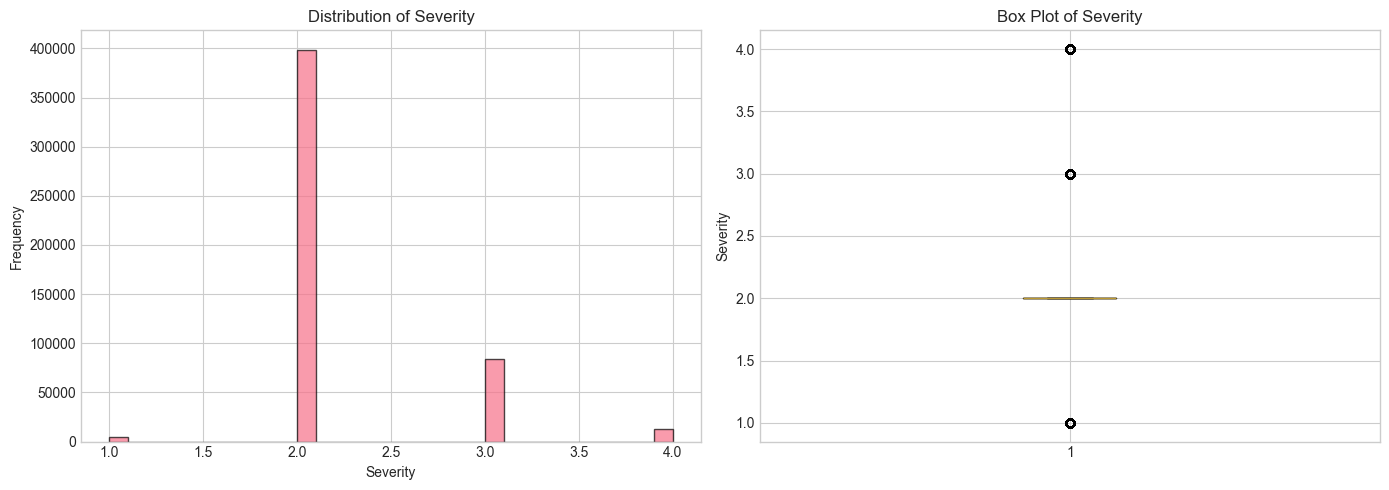


Skewness: 1.81
→ Target is highly skewed. Consider log transform in feature engineering.


In [488]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

### 3.2 Data Quality Checks

In [ ]:
#  Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})


missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)


print("Columns that have missing values:")
print(missing_df)


Columns that have missing values:
                       Missing Count  Missing %
End_Lat                       219978    43.9956
End_Lng                       219978    43.9956
Precipitation(in)             142366    28.4732
Wind_Chill(F)                 129188    25.8376
Wind_Speed(mph)                36902     7.3804
Visibility(mi)                 11482     2.2964
Wind_Direction                 11382     2.2764
Humidity(%)                    11371     2.2742
Weather_Condition              11300     2.2600
Temperature(F)                 10700     2.1400
Pressure(in)                    9170     1.8340
Weather_Timestamp               7842     1.5684
Sunrise_Sunset                  1561     0.3122
Nautical_Twilight               1561     0.3122
Astronomical_Twilight           1561     0.3122
Civil_Twilight                  1561     0.3122
Airport_Code                    1514     0.3028
Street                           654     0.1308
Timezone                         476     0.0952
Zipcod

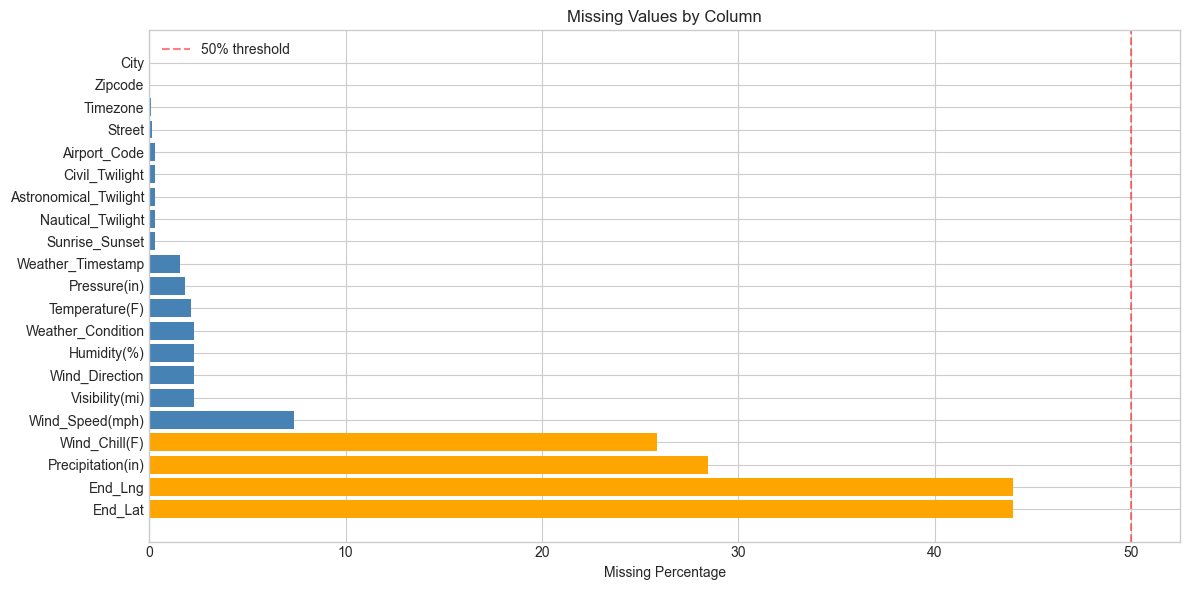

In [491]:
# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

## Section 4: Complete EDA

### 4.1 Numerical Features Analysis

In [492]:
# Get a list of numerical columns (excluding the target)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

numerical_cols.remove(TARGET)
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

Numerical features (12): ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']


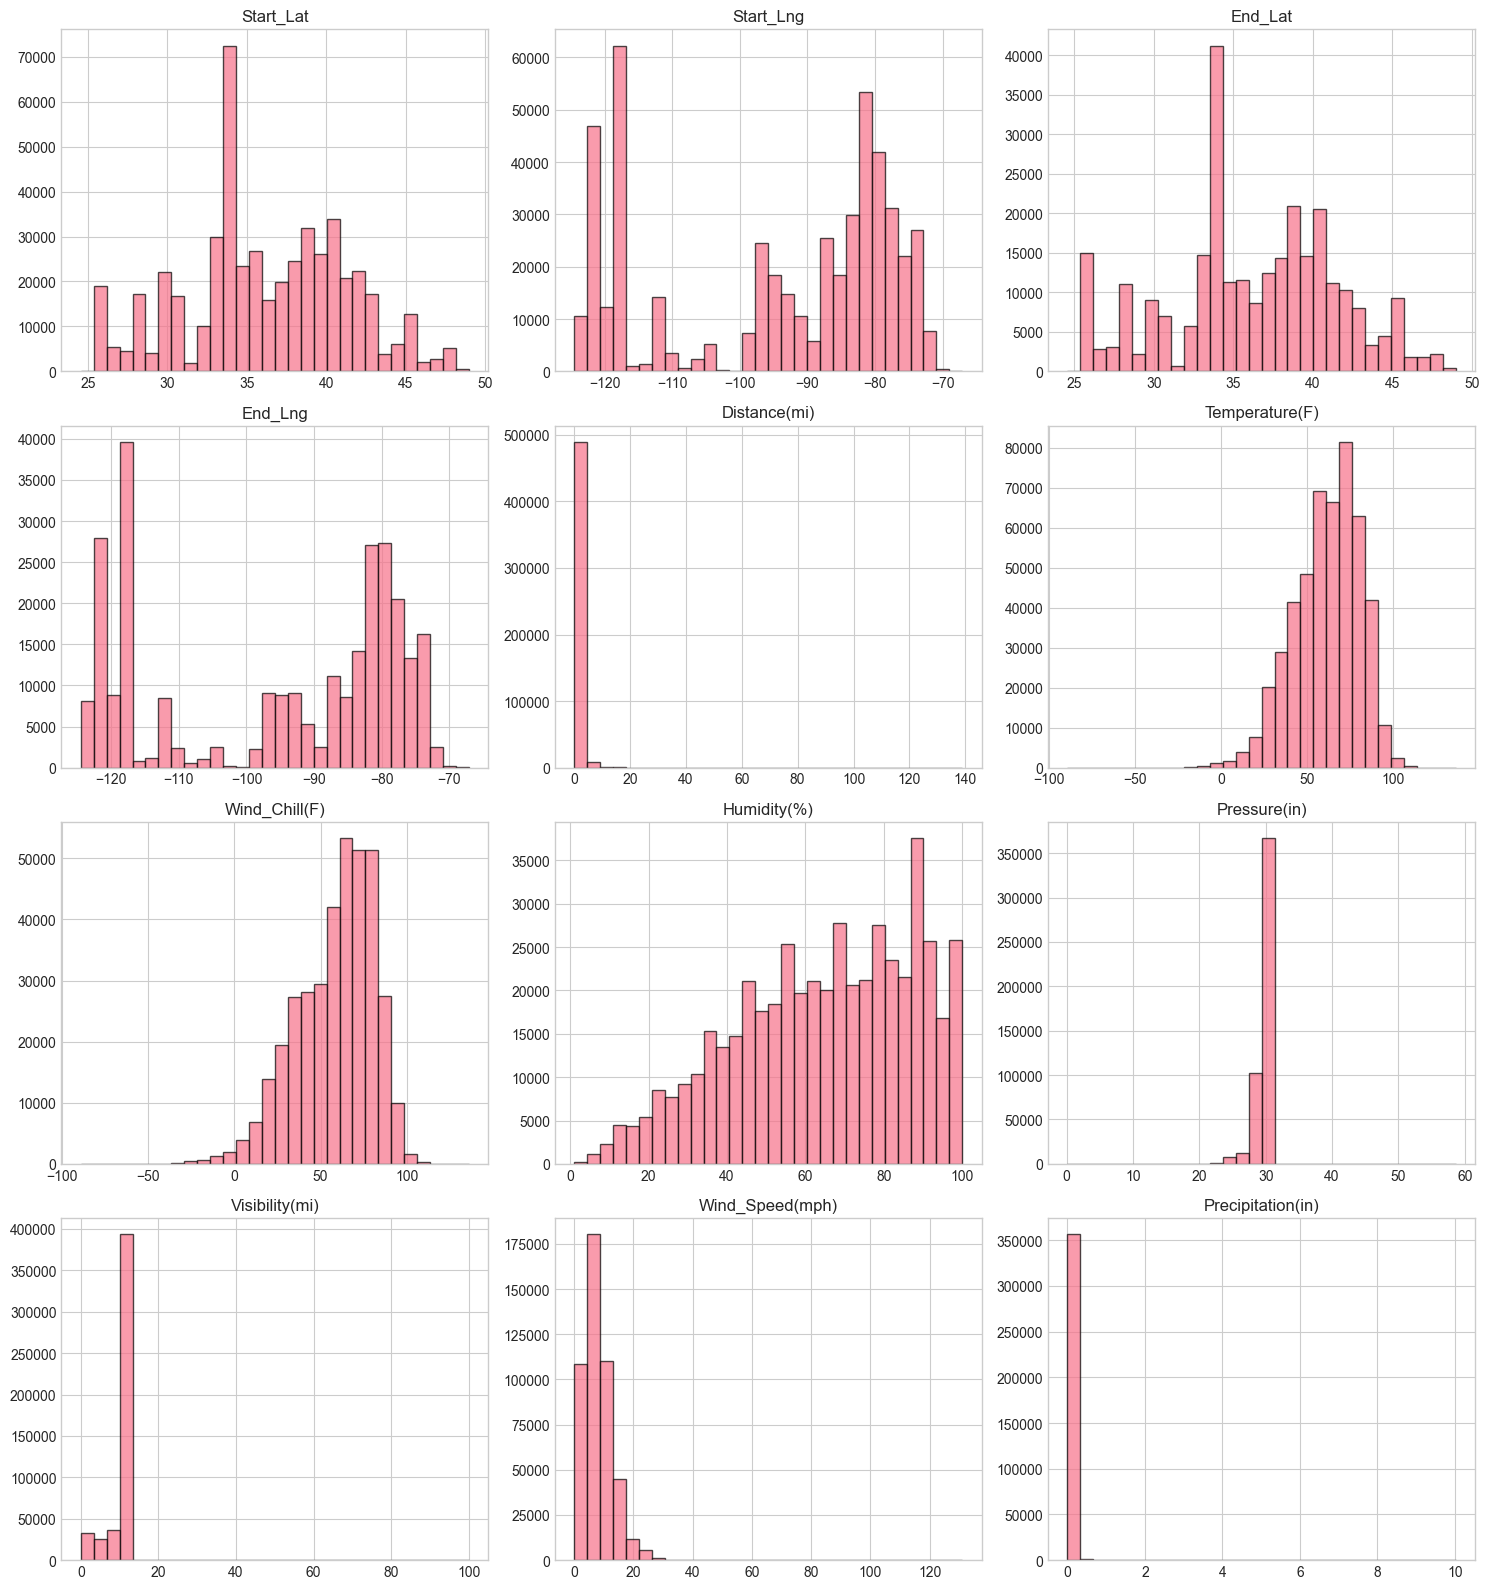

In [493]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

### 4.2 Categorical Features Analysis

In [494]:
# Get a list of categorical columns and explore their values

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Categorical columns: ({len(categorical_cols)}): {categorical_cols}")

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Top 10 value counts:\n{df[col].value_counts().head(10)}")

Categorical columns: (20): ['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Column: ID
Number of unique values: 500000
Top 10 value counts:
ID
a-1784167    1
a-862811     1
a-4054572    1
a-6147589    1
a-5025169    1
a-4007360    1
a-2185422    1
a-94012      1
a-6717568    1
a-2960129    1
Name: count, dtype: int64

Column: Source
Number of unique values: 3
Top 10 value counts:
Source
source1    280022
source2    213671
source3      6307
Name: count, dtype: int64

Column: Start_Time
Number of unique values: 486961
Top 10 value counts:
Start_Time
2021-01-26 16:16:13    10
2021-11-21 18:37:51     9
2021-02-16 06:42:43     8
2020-12-16 13:54:00     7
2017-05-15 09:22:55     7
2021-05-03 06:29:42     7
2021-11-09 13:10:00     7
2021-01-26 16:17:33     7

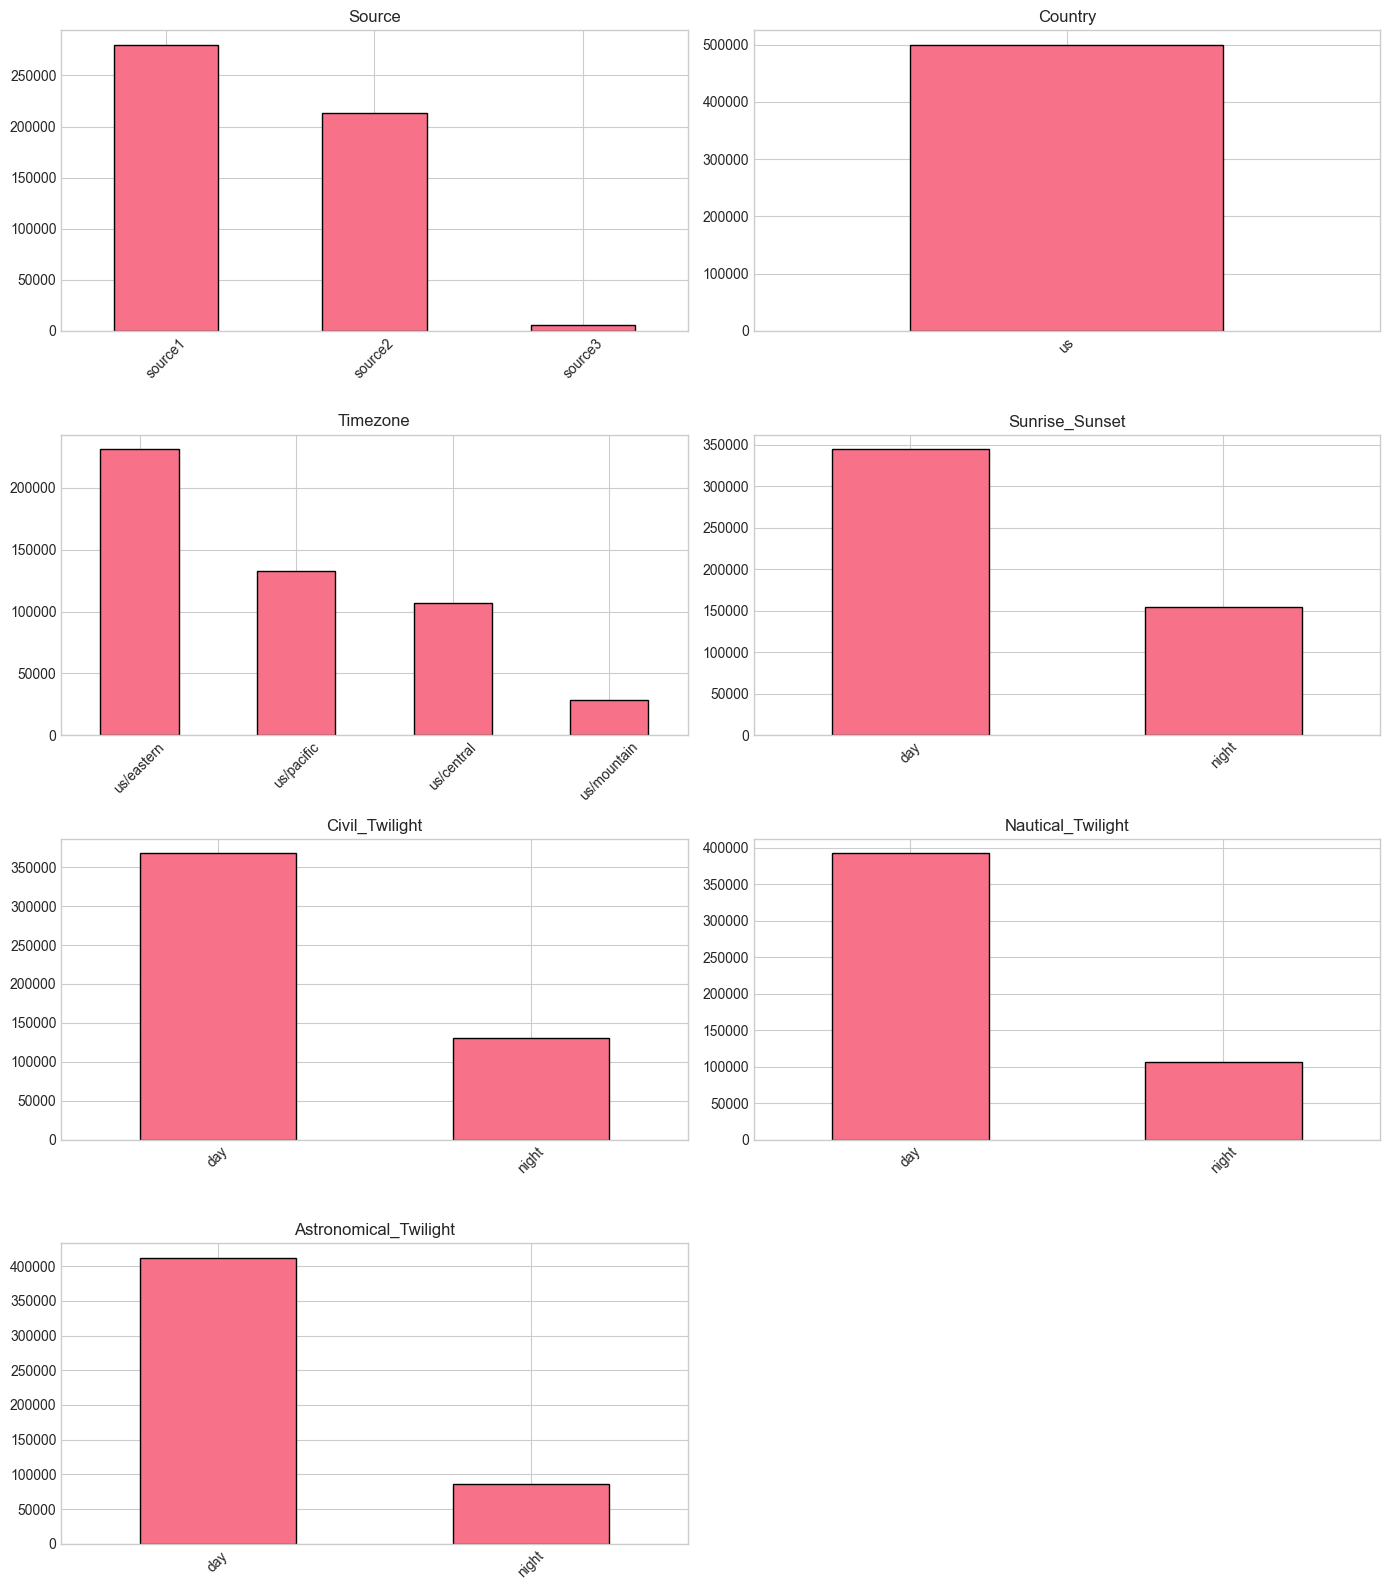

In [495]:
# Visualize categorical features (for columns with reasonable number of categories)
cat_cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 10]

if cat_cols_to_plot:
    n_cols = 2
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(cat_cols_to_plot) == 1 else axes
    
    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for j in range(len(cat_cols_to_plot), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with ≤10 unique values to plot.")

### 4.3 Categorical Features vs Target

*How does the target variable differ across categories?*

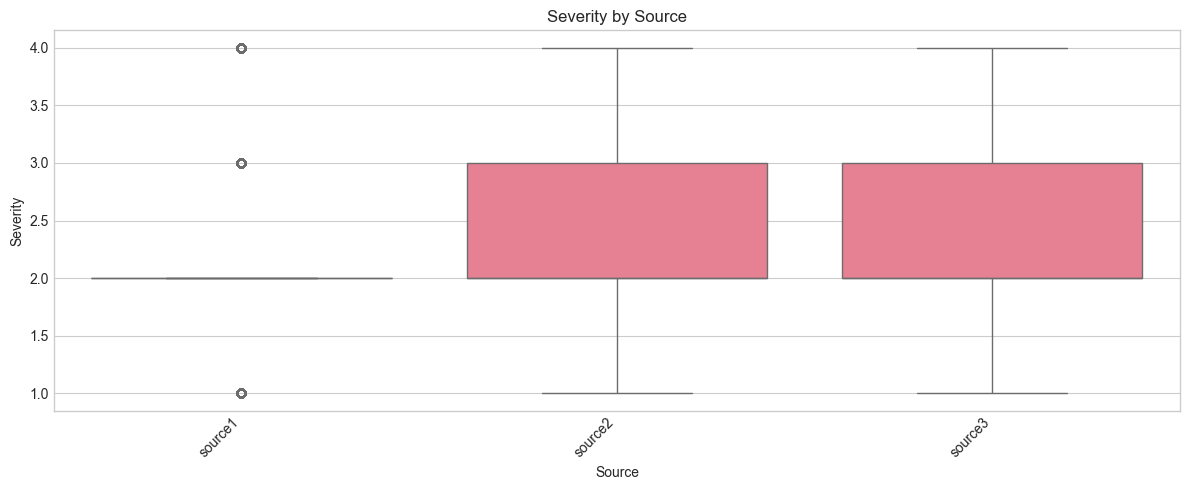


Mean Severity by Source:
             mean  median   count
Source                           
source2  2.333068     2.0  213671
source3  2.274774     2.0    6307
source1  2.118894     2.0  280022



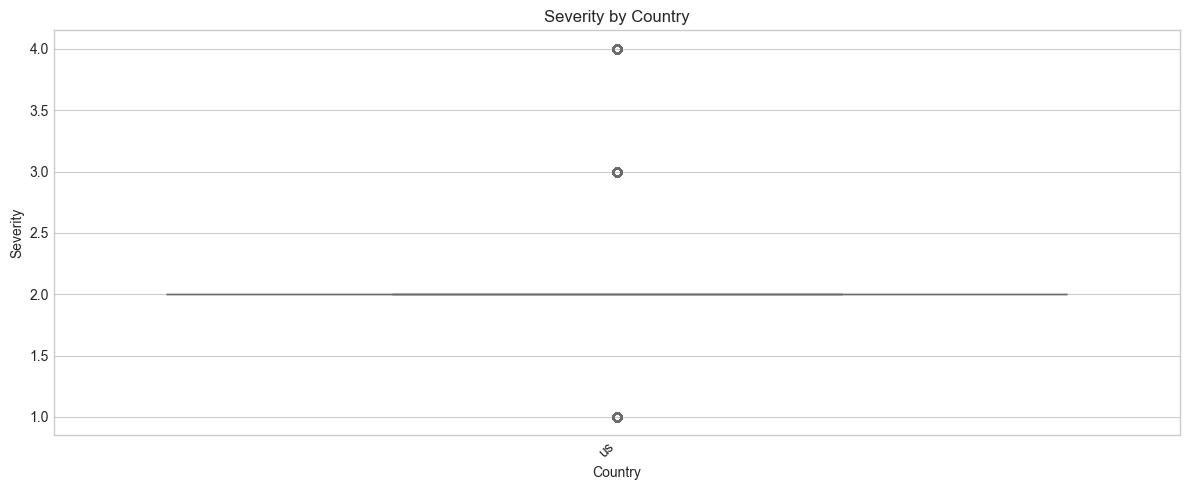


Mean Severity by Country:
             mean  median   count
Country                          
us       2.212386     2.0  500000



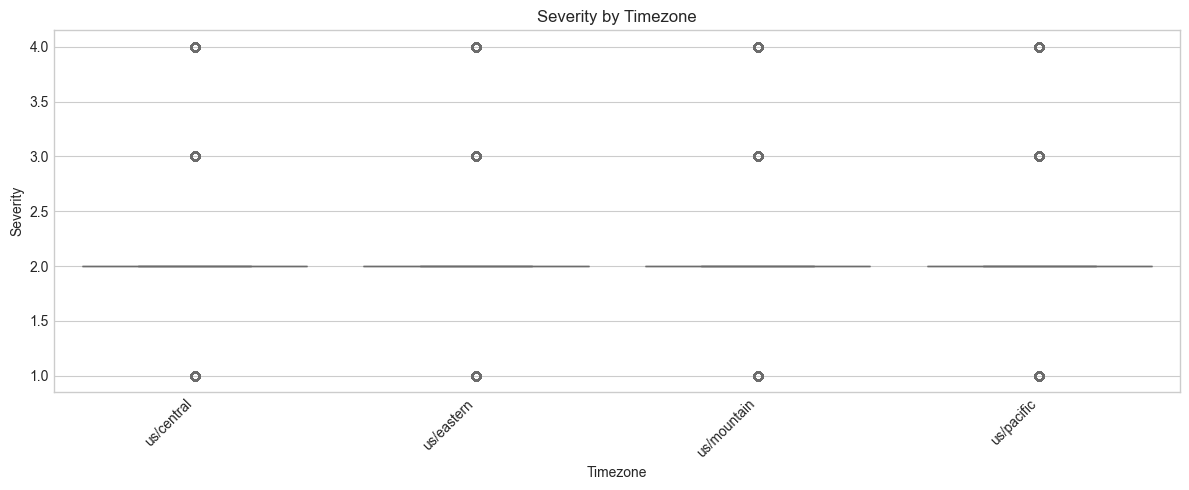


Mean Severity by Timezone:
                 mean  median   count
Timezone                             
us/central   2.235702     2.0  106677
us/eastern   2.228032     2.0  231503
us/mountain  2.204706     2.0   28221
us/pacific   2.168250     2.0  133123



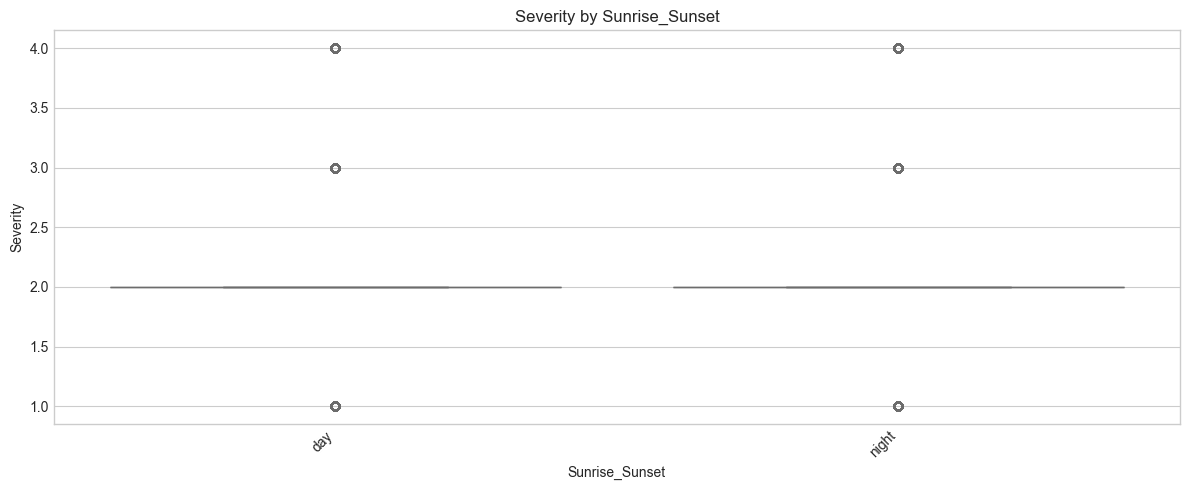


Mean Severity by Sunrise_Sunset:
                    mean  median   count
Sunrise_Sunset                          
night           2.218312     2.0  153844
day             2.209756     2.0  344595



In [496]:
# Box plots: Target by categorical features
cat_cols_to_analyze = [col for col in categorical_cols if df[col].nunique() <= 12]

if cat_cols_to_analyze:
    for col in cat_cols_to_analyze[:4]:  # Limit to first 4 for readability
        plt.figure(figsize=(12, 5))
        
        # Order by median target value
        order = df.groupby(col)[TARGET].median().sort_values().index
        
        sns.boxplot(data=df, x=col, y=TARGET, order=order)
        plt.title(f'{TARGET} by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Show mean target by category
        print(f"\nMean {TARGET} by {col}:")
        print(df.groupby(col)[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
        print("\n" + "="*50)
else:
    print("No suitable categorical columns for this analysis.")

### 4.4 Correlation Analysis

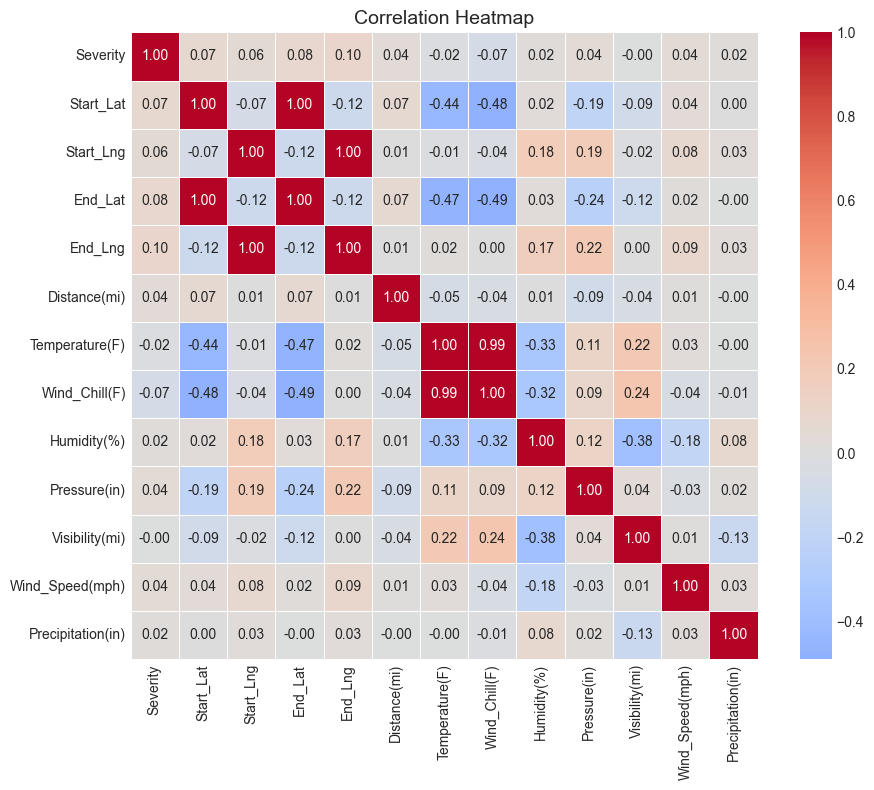

In [497]:
#  Create and visualize a correlation matrix

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Red = positive, Blue = negative
            center=0,             # Center the colormap at 0
            fmt='.2f',            # 2 decimal places
            square=True,          # Make cells square
            linewidths=0.5)       # Add grid lines

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [498]:
#  Extract and analyze correlations with the target variable

#remove TARGET column
target_correlations = correlation_matrix[TARGET].drop(labels=[TARGET]).sort_values(ascending=False)

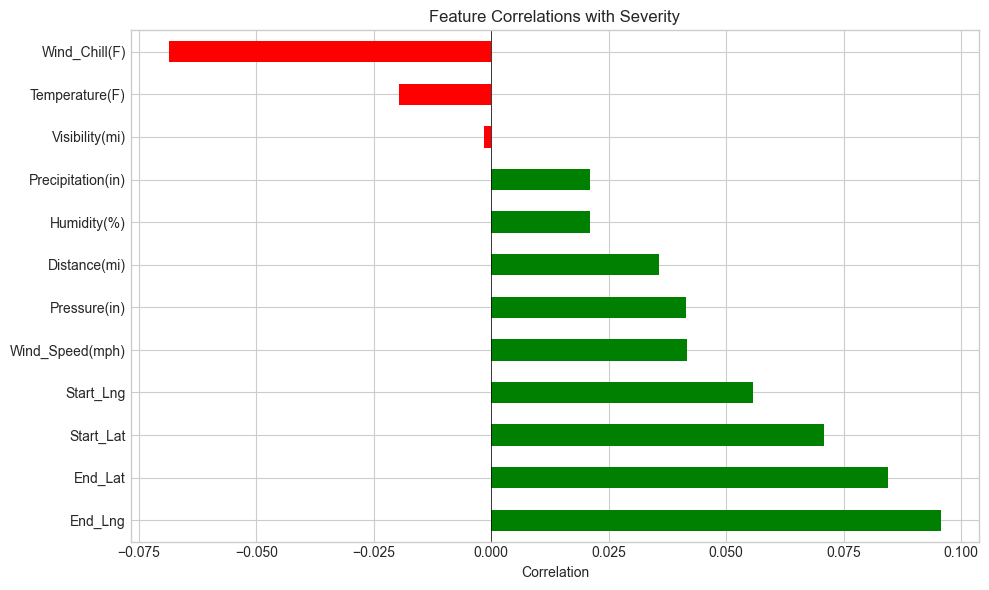

In [499]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.5 Feature vs Target Relationships

*Create scatter plots for your most promising numerical features against the target.*

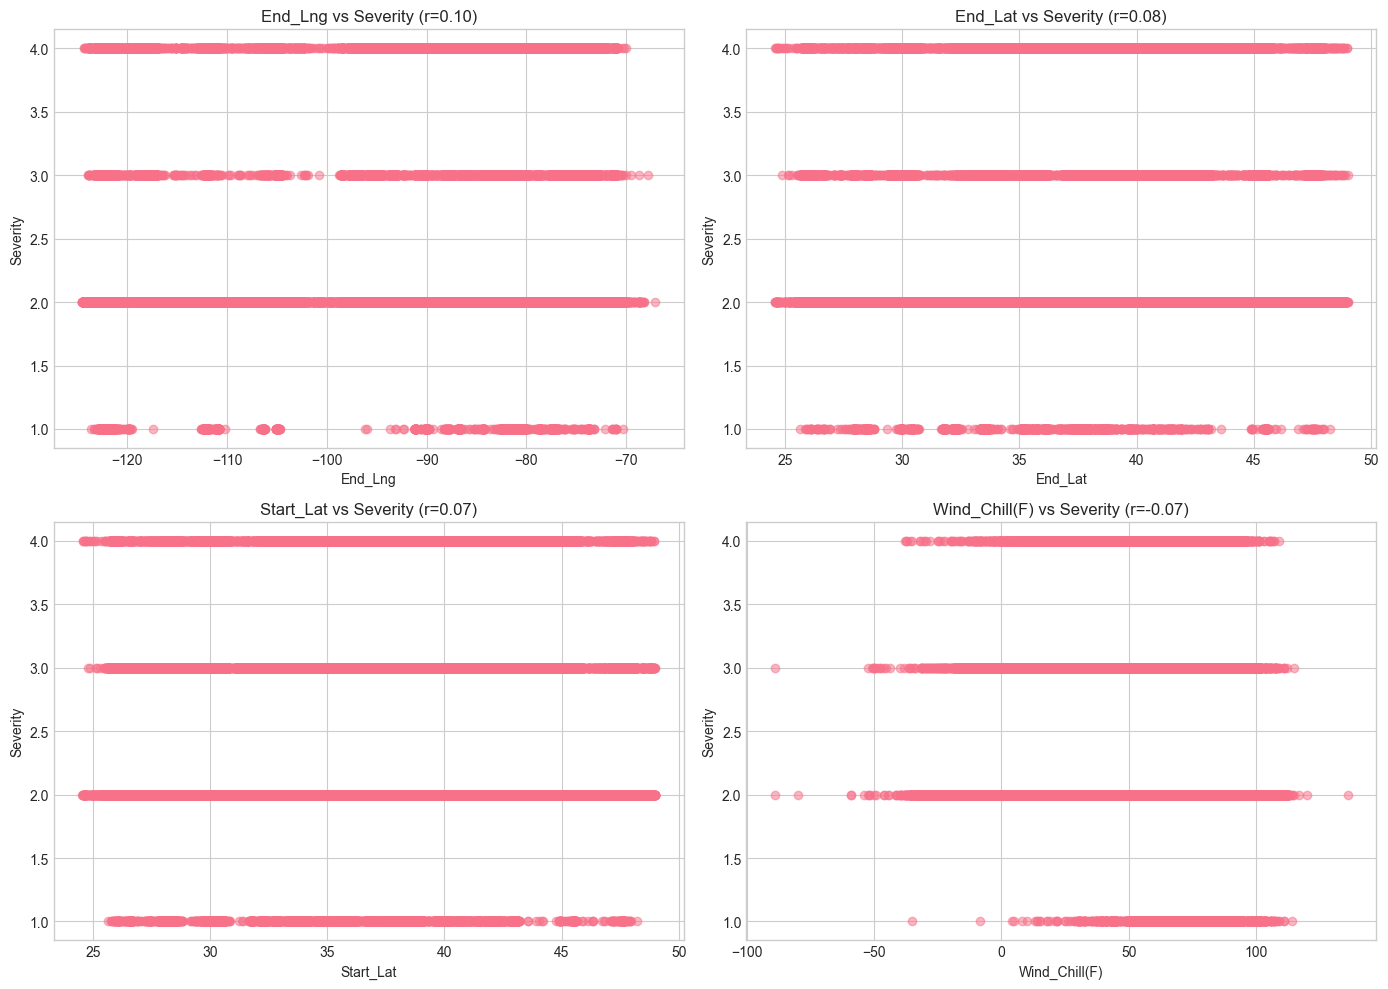

In [500]:
# Select top correlated features to plot
top_features = target_correlations.abs().sort_values(ascending=False).head(4).index.tolist()

if len(top_features) > 0:
    n_features = min(4, len(top_features))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:n_features]):
        axes[i].scatter(df[feature], df[TARGET], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(TARGET)
        corr = df[feature].corr(df[TARGET])
        axes[i].set_title(f'{feature} vs {TARGET} (r={corr:.2f})')

    # Hide unused subplots
    for j in range(n_features, 4):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot.")

### 4.6 Additional Exploration (Your Choice!)

The sections above provide a foundation, but every dataset is unique. Use the cells below to explore additional aspects of YOUR data that you think are important.

**Ideas for additional exploration:**
- Violin plots for categorical vs target (shows distribution shape)
- Look at feature interactions (e.g., does the relationship between X and Y change based on Z?)
- Explore geographic patterns (if you have location data)
- Create pair plots for key features (`sns.pairplot()`)
- Analyze distributions across different subgroups
- Look for data quality issues specific to your dataset
- Check for nonsensical values (negative prices, impossible ages, etc.)

**Remember:** The best insights often come from curiosity-driven exploration, not just following a template. What questions do YOU have about your data?

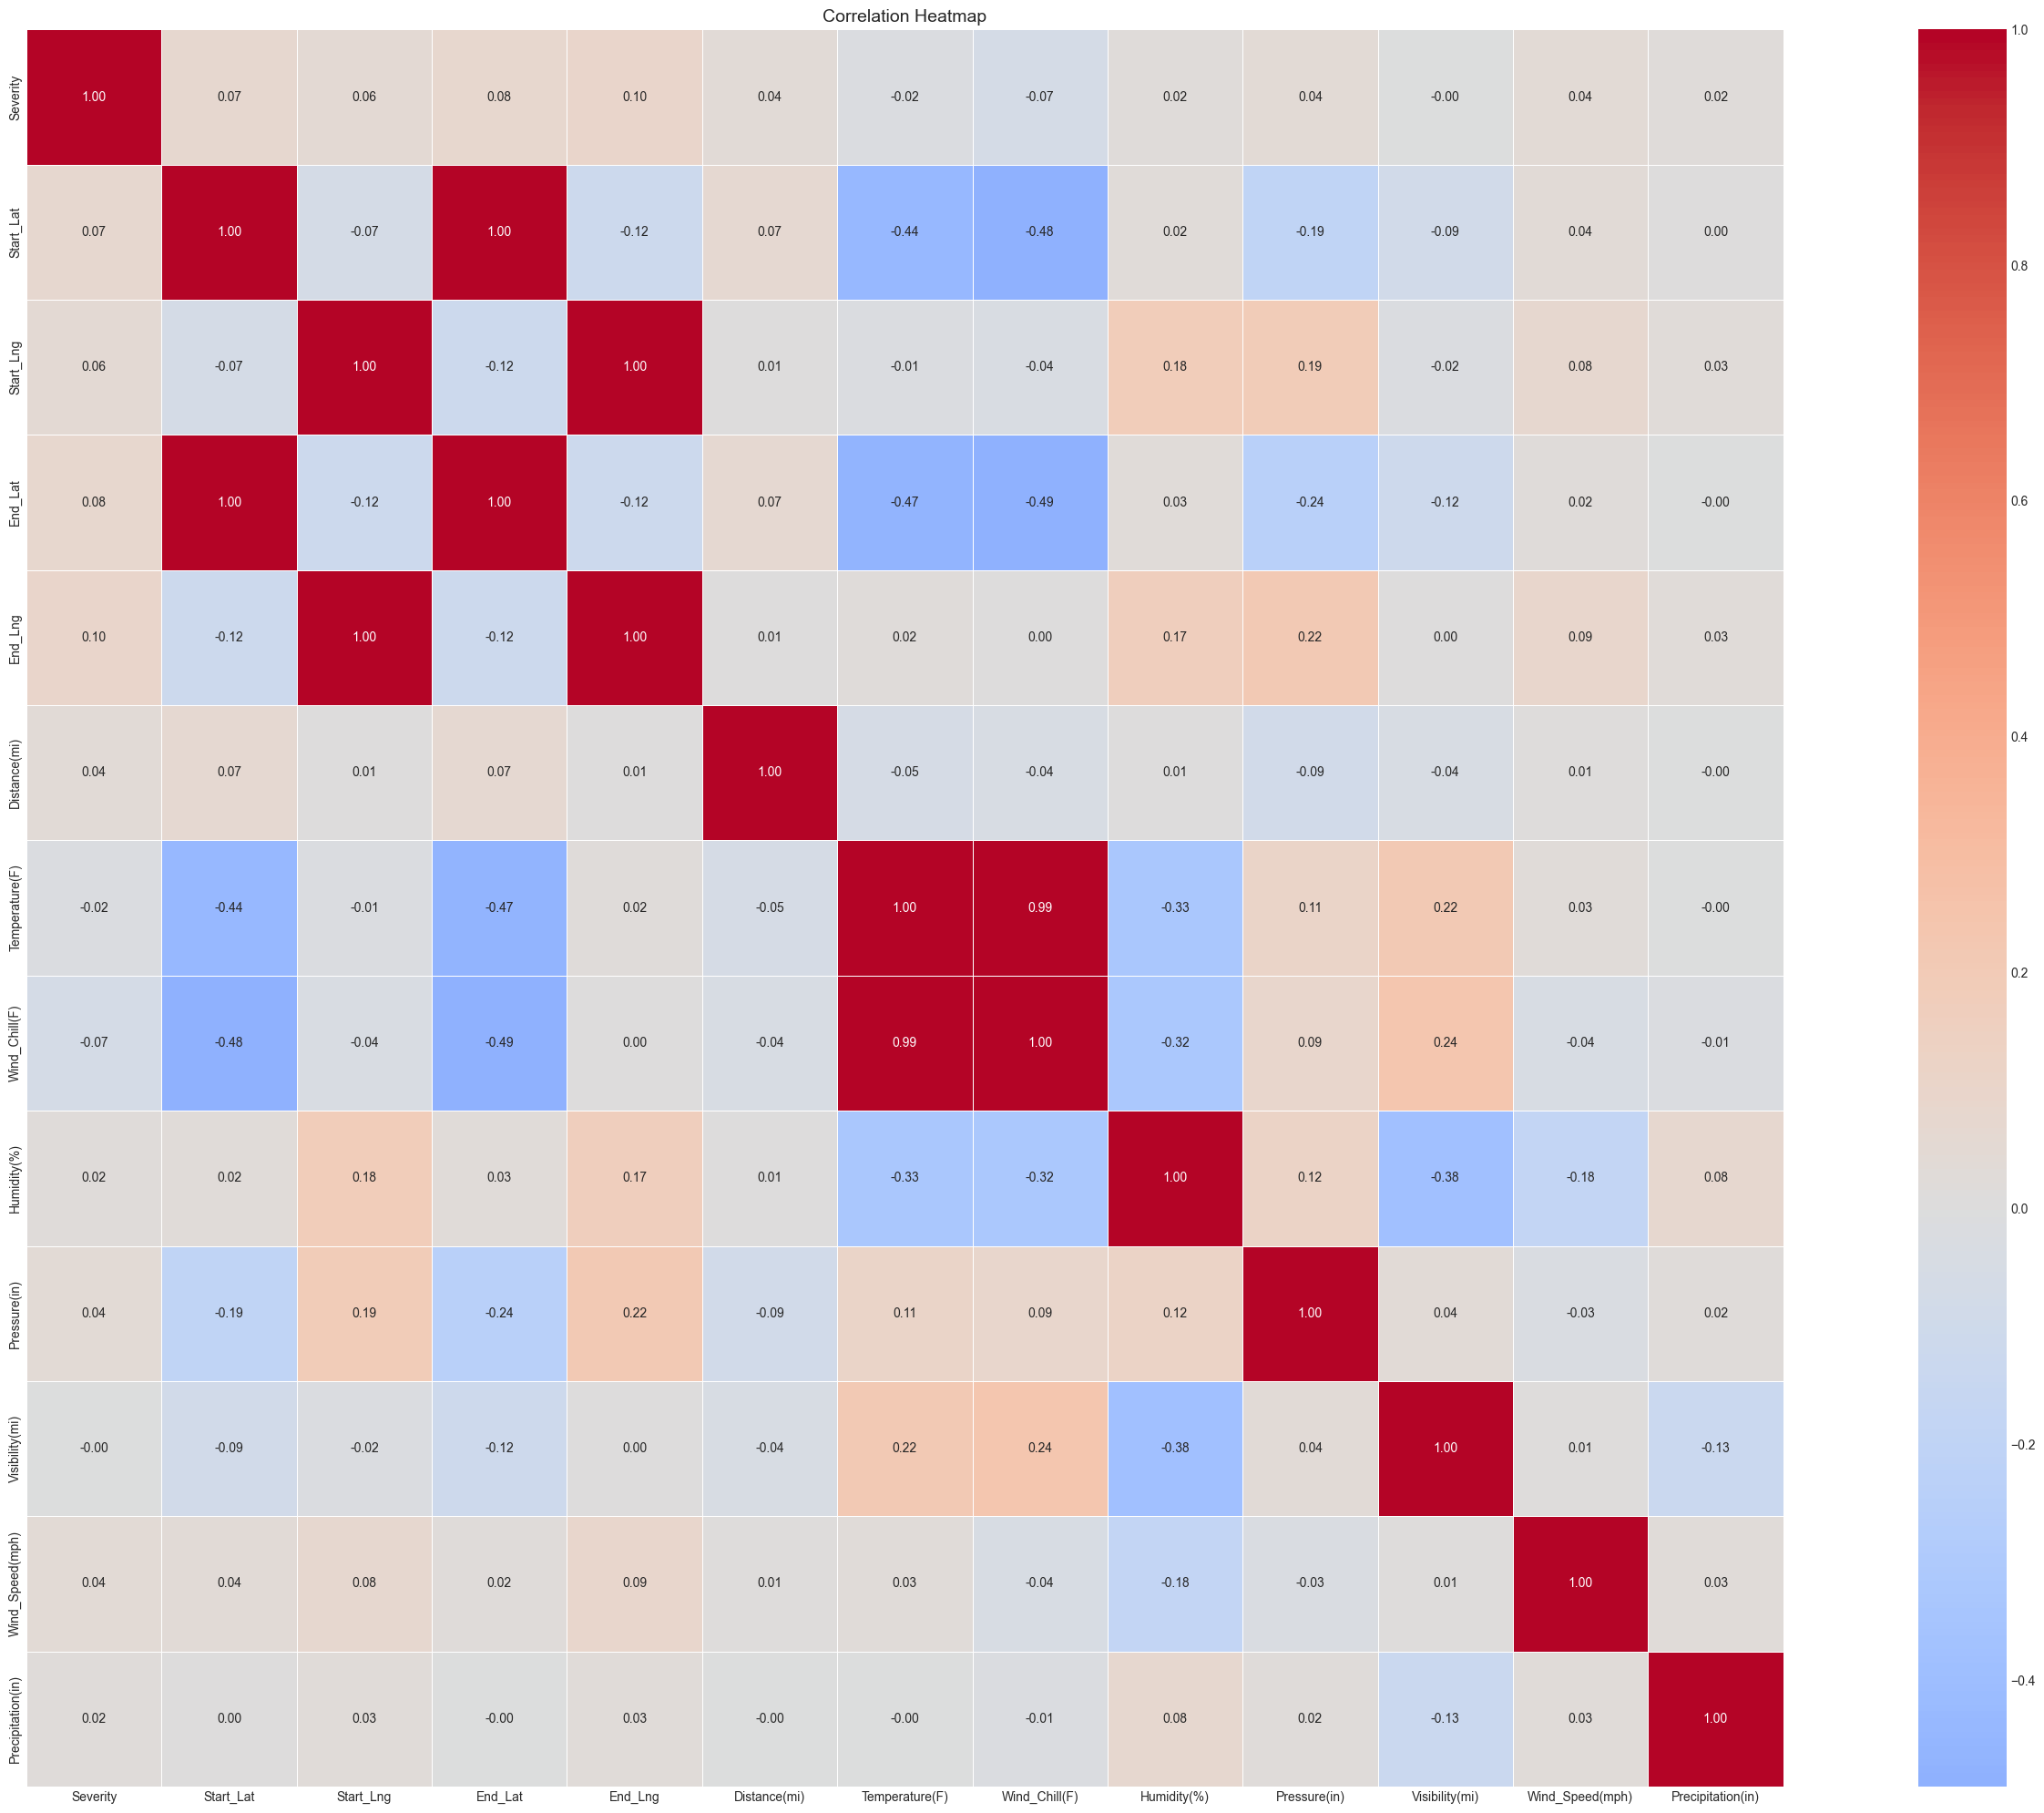

In [501]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(30, 20))

# Create the heatmap
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Red = positive, Blue = negative
            center=0,             # Center the colormap at 0
            fmt='.2f',            # 2 decimal places
            square=True,          # Make cells square
            linewidths=0.5)       # Add grid lines

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

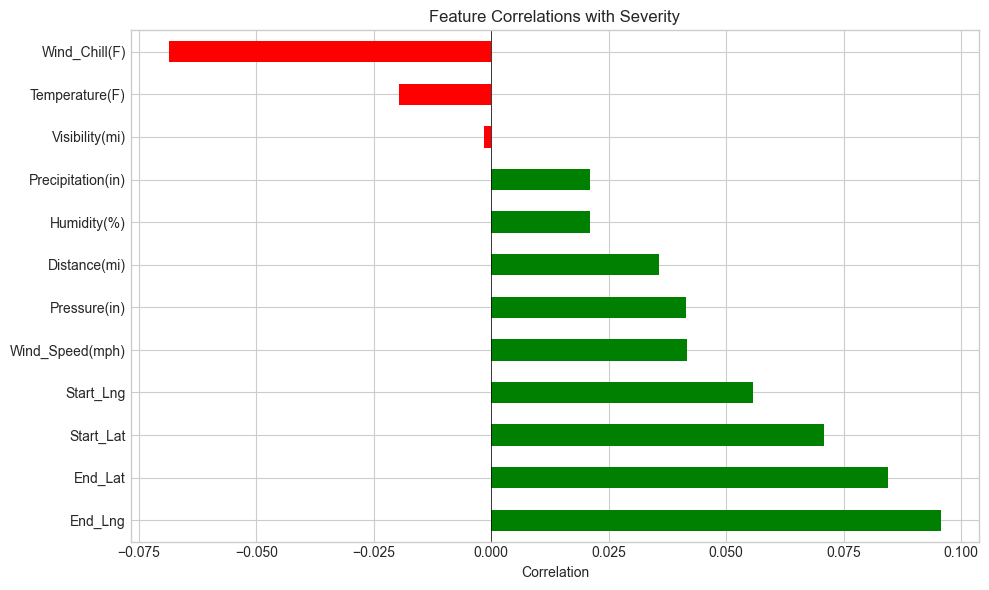

In [502]:
target_correlations = correlation_matrix[TARGET].drop(labels=[TARGET]).sort_values(ascending=False)
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.7 EDA Insights Summary

*Summarize your key findings from the EDA.*

**Questions to answer:**
- Which features are most correlated with your target?
- Which categorical features show the biggest differences in target?
- Are there any features that seem unimportant?
- Did you discover any interesting patterns or relationships?
- Are there any concerns about the data (outliers, skewness, etc.)?

**Your summary:**
 - what is Source? (Source1, Source2, Source3) imbalance
 - Country is US (removing)
 - Timezone (maybe not important)
 - Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight (very important) Day, Night
	we could encode like:
		LightLevel:
			0 = Day
			1 = Civil Twilight
			2 = Nautical Twilight
			3 = Astronomical Twilight
			4 = Night
 - Start_Lat	Start_Lng pretty much important I think
 - End_Lat	End_Lng (maybe not much important)?
 - we might use Timezone to calculate new features?! like hour? or maybe not, as we could use LightLevel
 - Temperature(F) / Wind_Chill(F) very correlated (lets use Temperature(F) filling values from Wind_Chill(F))
 - Wind_Speed(mph) I don't see any real correlation with severity

## Section 5: Data Cleaning

### 5.1 Decide What to Drop

Before cleaning, decide which columns to remove entirely.

In [503]:
#  Create a copy of your dataframe for cleaning

df_clean = df.copy()

print(f"Starting shape: {df_clean.shape}")

Starting shape: (500000, 46)


In [504]:
# Identify columns to potentially drop
print("Columns to consider dropping:")
print("="*50)

# 1. High missing rate
high_missing = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n1. >50% missing values: {high_missing}")

# 2. ID/index columns (no predictive value)
potential_ids = [col for col in df_clean.columns 
                 if 'id' in col.lower() or 'index' in col.lower() or 'url' in col.lower()]
print(f"\n2. Potential ID/URL columns: {potential_ids}")

# 3. High cardinality categorical (too many unique values)
high_cardinality = [col for col in categorical_cols if df_clean[col].nunique() > 100]
print(f"\n3. High cardinality (>100 unique): {high_cardinality}")

# 4. Low variance (same value in most rows)
low_variance = [col for col in df_clean.columns 
                if df_clean[col].value_counts(normalize=True).iloc[0] > 0.95]
print(f"\n4. Low variance (>95% same value): {low_variance}")

Columns to consider dropping:

1. >50% missing values: []

2. Potential ID/URL columns: ['ID', 'Humidity(%)']

3. High cardinality (>100 unique): ['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'Zipcode', 'Airport_Code', 'Weather_Timestamp', 'Weather_Condition']

4. Low variance (>95% same value): ['Country', 'Amenity', 'Bump', 'Give_Way', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Turning_Loop']


In [505]:
# Drop columns
#  Decide which columns to drop based on the analysis above
# IMPORTANT: Don't just copy all suggestions - think about each one!

columns_to_drop = [
    'ID',
    # 'Description',
    #'Distance(mi)', # probably not needed for modeling, and has some missing values
    'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Airport_Code', # Location details may be redundant with lat/lng, and have some missing values
    # latter I could try to use zip code!?
    'End_Lat', 'End_Lng', # These are highly correlated with Start_Lat and Start_Lng, and we filled missing values based on them, so we can drop them to avoid redundancy    
    'Timezone',
]

if columns_to_drop:
    df_clean = df_clean.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
    print(f"New shape: {df_clean.shape}")
else:
    print("No columns dropped. Update the list above if needed.")

Dropped 11 columns: ['ID', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Airport_Code', 'End_Lat', 'End_Lng', 'Timezone']
New shape: (500000, 35)


### 5.2 Handle Duplicate Rows

In [ ]:
# Remove duplicate rows from df_clean
# TODO: DO WE REALLY HAVE DUPLICATES? CHECK FIRST! --- IGNORE ---
row_count_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
row_count_after = len(df_clean)
print(f"Removed {row_count_before - row_count_after} duplicate rows.")

Removed 432 duplicate rows.


### 5.3 Handle Missing Values

In [507]:
# Check missing values in cleaned dataframe
print("Missing values before handling:")
missing_now = df_clean.isnull().sum()
missing_now = missing_now[missing_now > 0].sort_values(ascending=False)
print(missing_now)

Missing values before handling:
Precipitation(in)        142307
Wind_Chill(F)            129143
Wind_Speed(mph)           36878
Visibility(mi)            11465
Wind_Direction            11362
Humidity(%)               11353
Weather_Condition         11284
Temperature(F)            10682
Pressure(in)               9154
Weather_Timestamp          7827
Sunrise_Sunset             1560
Civil_Twilight             1560
Nautical_Twilight          1560
Astronomical_Twilight      1560
dtype: int64


### 5.4 Handle Outliers (if needed)

In [508]:
# Check for outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])
    return n_outliers, lower_bound, upper_bound

# Get current numerical columns
current_numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Outlier analysis:")
print("="*60)
for col in current_numerical:
    n_outliers, lower, upper = find_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        pct = n_outliers / len(df_clean) * 100
        print(f"{col}: {n_outliers:,} outliers ({pct:.1f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

Outlier analysis:
Severity: 101,638 outliers (20.3%) | bounds: [2.00, 2.00]
Distance(mi): 62,480 outliers (12.5%) | bounds: [-0.69, 1.16]
Temperature(F): 3,244 outliers (0.6%) | bounds: [8.50, 116.50]
Wind_Chill(F): 2,817 outliers (0.6%) | bounds: [-5.00, 123.00]
Pressure(in): 28,846 outliers (5.8%) | bounds: [28.38, 31.02]
Visibility(mi): 95,712 outliers (19.2%) | bounds: [10.00, 10.00]
Wind_Speed(mph): 13,799 outliers (2.8%) | bounds: [-4.10, 19.10]
Precipitation(in): 34,555 outliers (6.9%) | bounds: [0.00, 0.00]


### 5.5 Data Type Corrections

In [509]:
# Check current data types
print("Current data types:")
print(df_clean.dtypes)

Current data types:
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
Distance(mi)             float64
Description               object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bump                        bool
Crossing                    bool
Give_Way                    bool
Junction                    bool
No_Exit                     bool
Railway                     bool
Roundabout                  bool
Station                     bool
Stop                        bool
Traffic_Calming             bool
Traffic_Signal         

## Section 6: Feature Engineering

Feature engineering is where you can really add value! The sections below cover common techniques, but feel free to go beyond these basics.

### 6.1 Create New Features (if applicable)

**Common feature engineering techniques:**
- **Ratios/interactions:** Combine existing features (e.g., price per square foot)
- **Log transforms:** Reduce skewness in highly skewed features
- **Binning:** Convert continuous variables to categories
- **Text features:** Extract length, word counts, etc. from text
- **Domain-specific:** Features that make sense for your specific problem

Think about what would help YOUR specific prediction problem!

In [510]:
def dangerous_conditions_score(row): # A WAY TO COMBINE WEATHER CONDITIONS INTO A SINGLE RISK SCORE
    score = 0

    weather = str(row.get('Weather_Condition', '')).strip().lower()

    # Visibility
    visibility = row.get('Visibility(mi)')
    if pd.notna(visibility):
        if visibility < 1:
            score += 3
        elif visibility < 3:
            score += 2
        elif visibility < 5:
            score += 1

    # Precipitation amount
    precipitation = row.get('Precipitation(in)')
    if pd.notna(precipitation):
        if precipitation > 0.3:
            score += 2
        elif precipitation > 0:
            score += 1
    
    # Temperature / Wind Chill
    temp = row.get('Temperature(F)')
    wind_chill = row.get('Wind_Chill(F)')

    # Use wind chill if available (better for cold risk)
    effective_temp = wind_chill if pd.notna(wind_chill) else temp

    if pd.notna(effective_temp):
        if effective_temp < 32:
            score += 2   # freezing
        elif effective_temp > 100:
            score += 1   # extreme heat

    # Humidity
    humidity = row.get('Humidity(%)')
    if pd.notna(humidity) and humidity > 90:
        score += 1   # high humidity → fog potential
    
    # Pressure
    pressure = row.get('Pressure(in)')
    if pd.notna(pressure) and pressure < 29.5:
        score += 1   # storm indicator
        
    # Wind speed
    wind = row.get('Wind_Speed(mph)')
    if pd.notna(wind):
        if wind > 40:
            score += 2
        elif wind > 25:
            score += 1

    # Wind Direction (optional signal)
    wind_dir = str(row.get('Wind_Direction', '')).upper()

    # Gulf / coastal context → certain directions can be worse
    if wind_dir in ['N', 'NE', 'NW']:
        score += 0.5   # colder fronts / instability (small weight)

    # Darkness
    if row.get('Sunrise_Sunset') == 'Night':
        score += 1
    if row.get('Astronomical_Twilight') == 'Night':
        score += 1

    # Weather text categories
    severe_terms = [
        'tornado', 'thunderstorm', 't-storm', 'heavy t-storm',
        'heavy thunderstorms and rain', 'thunder in the vicinity',
        'hail', 'small hail', 'squalls', 'duststorm'
    ]

    winter_terms = [
        'heavy snow', 'snow and sleet', 'freezing rain',
        'light freezing rain', 'freezing drizzle',
        'heavy freezing drizzle', 'ice pellets',
        'light ice pellets', 'sleet', 'wintry mix',
        'blowing snow', 'drifting snow'
    ]

    low_visibility_terms = [
        'fog', 'mist', 'haze', 'smoke', 'blowing dust',
        'widespread dust', 'sand', 'dust whirl'
    ]

    moderate_terms = [
        'rain', 'drizzle', 'snow', 'showers', 'thunder'
    ]

    # Add points from text condition
    if any(term in weather for term in severe_terms):
        score += 3
    elif any(term in weather for term in winter_terms):
        score += 3
    elif any(term in weather for term in low_visibility_terms):
        score += 2
    elif any(term in weather for term in moderate_terms):
        score += 1

    # Windy modifier
    if 'windy' in weather:
        score += 1

    # Final label
    return score

In [511]:
df_clean['DangerousScore'] = df_clean.apply(dangerous_conditions_score, axis=1)

# remove the original weather condition columns to avoid data leakage
df_clean = df_clean.drop(columns=[
    'Temperature(F)', 
    'Wind_Chill(F)', 
    'Humidity(%)', 
    'Pressure(in)', 
    'Visibility(mi)', 
    'Wind_Direction', 
    'Wind_Speed(mph)', 
    'Precipitation(in)', 
    'Weather_Condition',
    
    'Weather_Timestamp',
    'Sunrise_Sunset',
    'Nautical_Twilight',
    'Civil_Twilight',
    'Astronomical_Twilight',
])

In [512]:

road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

existing = [f for f in road_features if f in df_clean.columns]

print(f"Existing road features: {existing}")

# Total road features present
df_clean['n_road_features'] = df_clean[existing].sum(axis=1)

# Traffic control present
control_features = ['Traffic_Signal', 'Stop', 'Give_Way', 'Traffic_Calming']
existing_control = [f for f in control_features if f in df_clean.columns]

df_clean['has_traffic_control'] = df_clean[existing_control].any(axis=1).astype(int)


print('df_clean columns after feature engineering:')
print(df_clean.columns)
# remove original road features
df_clean = df_clean.drop(columns=existing)
# df_clean = df_clean.drop(columns=existing_control)


Existing road features: ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']
df_clean columns after feature engineering:
Index(['Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Amenity', 'Bump',
       'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout',
       'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'DangerousScore', 'n_road_features', 'has_traffic_control'],
      dtype='object')


In [513]:
# define new feature based on time of day and day of week
df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'], format='mixed', errors='coerce')
df_clean['Hour'] = df_clean['Start_Time'].dt.hour
df_clean['DayOfWeek'] = df_clean['Start_Time'].dt.dayofweek

### 6.2 Encode Categorical Variables

In [514]:
#  Identify categorical columns that need encoding

categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"Column: {col}")
    print(f"Number of unique values: {df_clean[col].nunique()}")
    if df_clean[col].nunique() <= 10:
        print("Recommendation: one-hot encoding")
    else:
        print("Recommendation: consider label encoding or dropping")
    print()

cat_cols = categorical_cols

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df_clean[col].nunique()}")
    print(f"Top 10 value counts:\n{df_clean[col].value_counts().head(10)}")    

Column: Source
Number of unique values: 3
Recommendation: one-hot encoding

Column: End_Time
Number of unique values: 493706
Recommendation: consider label encoding or dropping

Column: Description
Number of unique values: 407442
Recommendation: consider label encoding or dropping


Column: Source
Number of unique values: 3
Top 10 value counts:
Source
source1    279599
source2    213662
source3      6307
Name: count, dtype: int64

Column: End_Time
Number of unique values: 493706
Top 10 value counts:
End_Time
2021-11-22 08:00:00    9
2017-05-15 15:22:55    7
2020-02-11 00:00:00    6
2020-02-07 00:00:00    6
2020-02-06 00:00:00    5
2020-02-14 00:00:00    5
2018-11-25 02:51:02    5
2022-08-30 02:45:00    5
2021-09-03 18:32:19    5
2021-02-04 05:01:28    4
Name: count, dtype: int64

Column: Description
Number of unique values: 407442
Top 10 value counts:
Description
a crash has occurred causing no to minimum delays. use caution.                                        606
accident         

In [515]:

df_clean = df_clean.drop(['Source', 'Start_Time', 'End_Time'], axis=1)

In [516]:
df_clean.head()

,Severity,Start_Lat,Start_Lng,Distance(mi),Description,DangerousScore,n_road_features,has_traffic_control,Hour,DayOfWeek
0,2,35.834797,-78.638512,0.000,accident on six forks rd at i-440 cliff benson...,0.0,0,0,13,1
1,2,36.088970,-96.011734,0.000,accident on i-44 eastbound at union ave.,3.0,0,0,6,2
2,2,33.537049,-86.794445,0.152,incident on i-20 wb near mm 126 road closed. t...,1.0,1,0,14,6
3,2,34.071722,-117.612886,0.869,slow traffic on i-10 w - san bernardino fwy w ...,1.0,0,0,19,4
4,2,40.324235,-76.790464,0.166,stationary traffic on us-22 e from i-81 n to s...,0.0,0,0,12,4


### 6.3 Additional Feature Engineering (Your Choice!)

Every dataset has unique opportunities for feature engineering. What else makes sense for YOUR data?

**Think about:**
- What domain knowledge can you apply?
- Are there any feature interactions that might be predictive?
- Can you create meaningful groups or categories?
- Would polynomial features help capture non-linear relationships?

In [517]:
# clean Description column

df_clean['Description'] = df_clean['Description'].str.lower().str.replace('[^\w\s]', '', regex=True)

# remove some common words that don't add much meaning
common_words = ['and', 'the', 'in', 'on', 'at', 'with', 'to', 'from', 'by', 'for', 'of', 
                'a', 'an', 'is', 'was', 'were', 'are', 'as', 'that', 'this', 'it',
                'due', 'caused', 'causing', 'after', 'before', 'during', 'near', 'around',
                'rd', 'st', 'ave', 'blvd', 'hwy', 'highway', 'street', 'road', 'avenue', 'boulevard',
                'near', 's', 'n', 'e', 'w', 'north', 'south', 'east', 'west',
                'dr', 'northbound', 'southbound', 'eastbound', 'westbound',
                'drive', 'fwy', 'i95', 'i10', 'i5', 'i80', 'us101', 
                'ln', 'nb', 'sb', 'eb', 'wb',
                'right', 'left', 'front', 'rear', 
                'lane'
                ]
pattern = r'\b(' + '|'.join(common_words) + r')\b'
df_clean['Description'] = df_clean['Description'].str.replace(pattern, '', regex=True)

# from description column extract keywords based on the most common words in the text
most_common_words = df_clean['Description'].str.lower().str.split(expand=True).stack().value_counts()

# print the top 30 most common words
print(most_common_words.head(30))

accident      368643
blocked       110847
incident       93336
exit           89352
traffic        85773
caution        61466
slow           47007
closed         43218
stationary     36449
shoulder       29729
crash          27466
delays         24606
expect         23171
pkwy           20811
hand           20695
exits          18936
between        18056
lanes          17324
rdexit         15122
county         13342
ramp           10986
aveexit        10027
i75             9808
1               9781
route           9733
alternate       9514
stexit          9171
take            9009
house           8728
expy            8712
Name: count, dtype: int64


In [518]:
most_significant_words = ['accident','block', 'incident', 'exit', 'traffic', 'caution', 'slow', 'close', 'stationary'
                          'crash', 'delay', 'expect'
                          ]

In [519]:
# create a function to count the number of significant words in the description
def count_significant_words(text):
    if pd.isna(text):
        return 0
    # text = text.lower()
    count = sum(text.count(word) for word in most_significant_words)
    return count

In [520]:
df_clean['SignificantWordCount'] = df_clean['Description'].apply(count_significant_words)

# drop the original description column
df_clean = df_clean.drop('Description', axis=1)

df_clean.head()

,Severity,Start_Lat,Start_Lng,Distance(mi),DangerousScore,n_road_features,has_traffic_control,Hour,DayOfWeek,SignificantWordCount
0,2,35.834797,-78.638512,0.000,0.0,0,0,13,1,2
1,2,36.088970,-96.011734,0.000,3.0,0,0,6,2,1
2,2,33.537049,-86.794445,0.152,1.0,1,0,14,6,2
3,2,34.071722,-117.612886,0.869,1.0,0,0,19,4,3
4,2,40.324235,-76.790464,0.166,0.0,0,0,12,4,2


**Explain your additional feature engineering:**

We did not create any additional features. However, I added some visualizations to better understand the relationship between the route index and the duration of each route. Once again, route index appears to have a strong influence on the duration, which is consistent with our expectations.

### 6.4 Feature Scaling (Preparation)

We'll do actual scaling in the modeling notebook, but let's check which features might need it.

In [521]:
#  Identify numerical features and check their ranges

numerical_features = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features.remove(TARGET)  # Exclude the target column

for col in numerical_features:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    print(f"{col}: min={min_val}, max={max_val}, range={max_val - min_val}")

Start_Lat: min=24.555269, max=48.993996, range=24.438727000000004
Start_Lng: min=-124.49758500000002, max=-67.113167, range=57.38441800000001
Distance(mi): min=0.0, max=138.91000366210938, range=138.91000366210938
DangerousScore: min=0.0, max=13.0, range=13.0
n_road_features: min=0, max=6, range=6
has_traffic_control: min=0, max=1, range=1
SignificantWordCount: min=0, max=14, range=14


### 6.5 Final Sanity Checks

In [522]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 499,568 rows, 10 columns
   (Started with 500,000 rows, 46 columns)

2. Missing values: 0

3. Duplicate rows: 2670

4. Target variable 'Severity':
   - Min: 1.00
   - Max: 4.00
   - Mean: 2.21

5. Data types:
   - Numerical: 10
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


### 6.6 Save Processed Data

In [523]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (499568, 10)

Columns (10):
['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'DangerousScore', 'n_road_features', 'has_traffic_control', 'Hour', 'DayOfWeek', 'SignificantWordCount']

Data types:
Severity                  int64
Start_Lat               float64
Start_Lng               float64
Distance(mi)            float64
DangerousScore          float64
n_road_features           int64
has_traffic_control       int64
Hour                      int32
DayOfWeek                 int32
SignificantWordCount      int64
dtype: object


In [524]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv
